In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
x=pd.read_csv("C:\\Users\\DELL\\Downloads\\hr_employee_attrition_dataset.csv")
x

,Employee_ID,Age,Gender,Department,JobRole,MonthlyIncome,YearsAtCompany,JobSatisfaction,Attrition,OverTime,EducationField
0,1,29,Male,Operations,Manager,112196,0,1,Yes,No,HR
1,2,49,Male,Marketing,Executive,18905,1,4,Yes,Yes,Technical
2,3,50,Male,Operations,Engineer,51463,18,3,No,Yes,Marketing
3,4,31,Female,Sales,Analyst,115072,6,3,Yes,No,HR
4,5,38,Female,Sales,Clerk,110647,1,3,No,No,HR
...,...,...,...,...,...,...,...,...,...,...,...
495,496,48,Female,HR,Analyst,82699,11,1,No,Yes,Finance
496,497,43,Female,HR,Clerk,87686,2,3,Yes,Yes,Technical
497,498,34,Male,IT,Executive,111614,15,2,Yes,Yes,Technical
498,499,37,Male,Sales,Consultant,61665,19,4,No,Yes,HR


In [4]:
x.head()

,Employee_ID,Age,Gender,Department,JobRole,MonthlyIncome,YearsAtCompany,JobSatisfaction,Attrition,OverTime,EducationField
0,1,29,Male,Operations,Manager,112196,0,1,Yes,No,HR
1,2,49,Male,Marketing,Executive,18905,1,4,Yes,Yes,Technical
2,3,50,Male,Operations,Engineer,51463,18,3,No,Yes,Marketing
3,4,31,Female,Sales,Analyst,115072,6,3,Yes,No,HR
4,5,38,Female,Sales,Clerk,110647,1,3,No,No,HR


In [5]:
x.tail()

,Employee_ID,Age,Gender,Department,JobRole,MonthlyIncome,YearsAtCompany,JobSatisfaction,Attrition,OverTime,EducationField
495,496,48,Female,HR,Analyst,82699,11,1,No,Yes,Finance
496,497,43,Female,HR,Clerk,87686,2,3,Yes,Yes,Technical
497,498,34,Male,IT,Executive,111614,15,2,Yes,Yes,Technical
498,499,37,Male,Sales,Consultant,61665,19,4,No,Yes,HR
499,500,22,Female,Finance,Clerk,20539,17,3,No,No,Finance


In [7]:
x.describe()

,Employee_ID,Age,MonthlyIncome,YearsAtCompany,JobSatisfaction
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,41.492000,69601.372000,10.118000,2.484000
std,144.481833,11.187325,30747.928417,6.162795,1.135042
min,1.000000,22.000000,15037.000000,0.000000,1.000000
25%,125.750000,31.000000,43228.500000,4.750000,1.000000
50%,250.500000,41.500000,69517.500000,10.000000,2.000000
75%,375.250000,51.000000,98876.500000,15.000000,4.000000
max,500.000000,60.000000,119771.000000,20.000000,4.000000


In [8]:
x.info

<bound method DataFrame.info of      Employee_ID  Age  Gender  Department     JobRole  MonthlyIncome  \
0              1   29    Male  Operations     Manager         112196   
1              2   49    Male   Marketing   Executive          18905   
2              3   50    Male  Operations    Engineer          51463   
3              4   31  Female       Sales     Analyst         115072   
4              5   38  Female       Sales       Clerk         110647   
..           ...  ...     ...         ...         ...            ...   
495          496   48  Female          HR     Analyst          82699   
496          497   43  Female          HR       Clerk          87686   
497          498   34    Male          IT   Executive         111614   
498          499   37    Male       Sales  Consultant          61665   
499          500   22  Female     Finance       Clerk          20539   

     YearsAtCompany  JobSatisfaction Attrition OverTime EducationField  
0                 0           

In [14]:
x["Department"]

0      Operations
1       Marketing
2      Operations
3           Sales
4           Sales
          ...    
495            HR
496            HR
497            IT
498         Sales
499       Finance
Name: Department, Length: 500, dtype: object

In [2]:
x.groupby('Department')["Attrition"].count()

Department
Finance       92
HR            80
IT            89
Marketing     93
Operations    76
Sales         70
Name: Attrition, dtype: int64

In [4]:
x.groupby("Gender")["Attrition"].count()

Gender
Female    244
Male      256
Name: Attrition, dtype: int64

In [12]:
x.groupby('JobRole')["JobRole"].count()

JobRole
Analyst       78
Clerk         90
Consultant    84
Engineer      80
Executive     81
Manager       87
Name: JobRole, dtype: int64

In [13]:
len(x)

500

In [15]:
x[x["Attrition"]=="Yes"].shape[0]

138

In [16]:
x[x["Attrition"]=="No"].shape[0]

362

In [18]:
round((x["Attrition"].value_counts()["Yes"] / len(x)) * 100, 2)

np.float64(27.6)

In [21]:
x[x["Attrition"]=="Yes"].groupby("Department").size()

Department
Finance       19
HR            22
IT            33
Marketing     28
Operations    19
Sales         17
dtype: int64

In [41]:
z=x["Gender"].value_counts()
z

Gender
Male      256
Female    244
Name: count, dtype: int64

In [23]:
x["Attrition"].value_counts()

Attrition
No     362
Yes    138
Name: count, dtype: int64

In [3]:
pd.crosstab(x["Gender"], x["Attrition"])

Attrition,No,Yes
Gender,,
Female,177,67
Male,185,71


In [25]:
x["MonthlyIncome"].mean()

np.float64(69601.372)

In [27]:
x.groupby("Department")["MonthlyIncome"].mean()

Department
Finance       73497.989130
HR            67830.912500
IT            68660.146067
Marketing     68434.913978
Operations    66947.342105
Sales         72131.428571
Name: MonthlyIncome, dtype: float64

In [28]:
pd.crosstab(x["OverTime"], x["Attrition"])

Attrition,No,Yes
OverTime,,
No,193,65
Yes,169,73


In [36]:
y=x[x["Attrition"]=="Yes"]["JobRole"].value_counts()
y

JobRole
Clerk         36
Manager       24
Executive     22
Consultant    21
Analyst       19
Engineer      16
Name: count, dtype: int64

In [30]:
x["Age"].mean()

np.float64(41.492)

In [31]:
bins = [20,30,40,50,60]
labels = ["20-30","31-40","41-50","51-60"]

x["AgeGroup"] = pd.cut(x["Age"], bins=bins, labels=labels)

pd.crosstab(x["AgeGroup"], x["Attrition"])

Attrition,No,Yes
AgeGroup,,
20-30,84,28
31-40,84,38
41-50,89,42
51-60,105,30


In [32]:
x.groupby("Attrition")["YearsAtCompany"].mean()

Attrition
No     10.140884
Yes    10.057971
Name: YearsAtCompany, dtype: float64

In [33]:
pd.crosstab(x["JobSatisfaction"], x["Attrition"])

Attrition,No,Yes
JobSatisfaction,,
1,91,42
2,84,34
3,92,31
4,95,31


In [34]:
x.corr(numeric_only=True)

,Employee_ID,Age,MonthlyIncome,YearsAtCompany,JobSatisfaction
Employee_ID,1.000000,-0.062336,0.023248,0.026800,0.015568
Age,-0.062336,1.000000,-0.013795,0.015027,0.020506
MonthlyIncome,0.023248,-0.013795,1.000000,-0.085377,0.005706
YearsAtCompany,0.026800,0.015027,-0.085377,1.000000,-0.068057
JobSatisfaction,0.015568,0.020506,0.005706,-0.068057,1.000000


<Axes: xlabel='JobRole'>

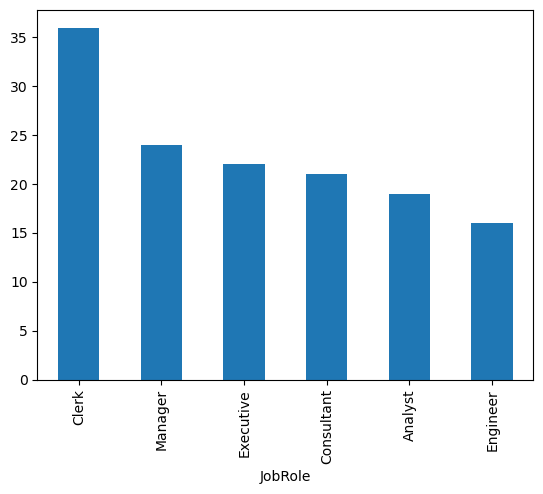

In [38]:
y.plot(kind='bar')

<Axes: ylabel='count'>

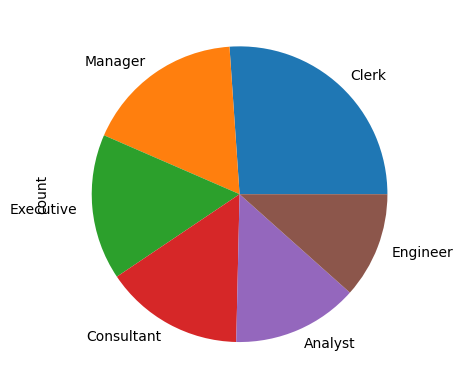

In [40]:
y.plot(kind='pie')

<Axes: ylabel='count'>

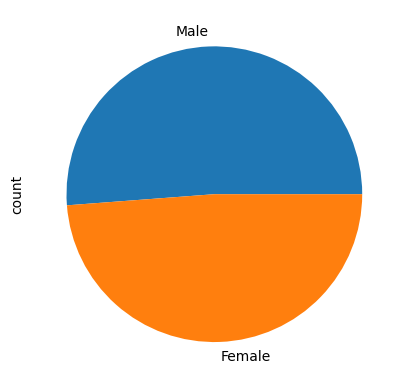

In [43]:
z.plot(kind='pie')

In [16]:
a=x[x["Attrition"]=="Yes"]["Department"].value_counts()
a

Department
IT            33
Marketing     28
HR            22
Operations    19
Finance       19
Sales         17
Name: count, dtype: int64

In [18]:
b=x.groupby("Department")["Attrition"].count()
b

Department
Finance       92
HR            80
IT            89
Marketing     93
Operations    76
Sales         70
Name: Attrition, dtype: int64

In [23]:
d=x[x["OverTime"]=="Yes"]["JobRole"].value_counts()
d

JobRole
Manager       47
Executive     43
Clerk         39
Analyst       39
Engineer      38
Consultant    36
Name: count, dtype: int64

In [25]:
e=x.groupby("JobRole")["OverTime"].count()
e

JobRole
Analyst       78
Clerk         90
Consultant    84
Engineer      80
Executive     81
Manager       87
Name: OverTime, dtype: int64

In [13]:
x.groupby("JobSatisfaction")["Attrition"].count()

JobSatisfaction
1    133
2    118
3    123
4    126
Name: Attrition, dtype: int64

In [14]:
x[x["Attrition"]=="Yes"]["JobSatisfaction"].value_counts()

JobSatisfaction
1    42
2    34
4    31
3    31
Name: count, dtype: int64

In [19]:
c=a/b

In [21]:
round(c,2)

Department
Finance       0.21
HR            0.28
IT            0.37
Marketing     0.30
Operations    0.25
Sales         0.24
dtype: float64

In [28]:
f=d/e
f

JobRole
Analyst       0.500000
Clerk         0.433333
Consultant    0.428571
Engineer      0.475000
Executive     0.530864
Manager       0.540230
dtype: float64

<Axes: xlabel='JobRole'>

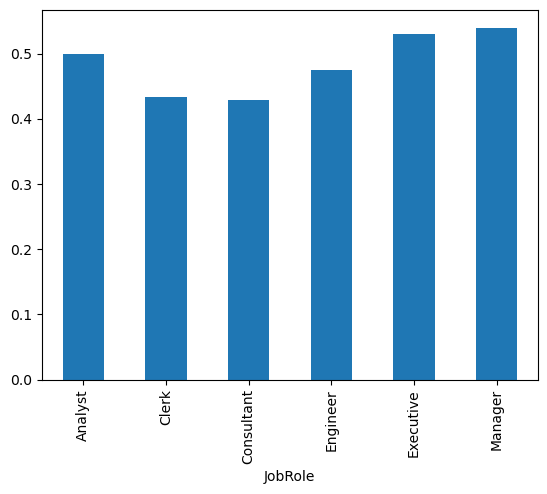

In [29]:
f.plot(kind="bar")

<Axes: >

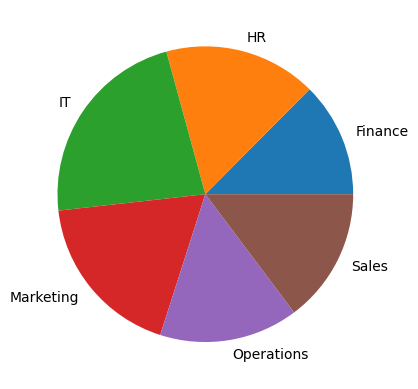

In [31]:
c.plot(kind="pie")